In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Product Detail

In [2]:
# Import data
detail = pd.read_csv('../data/raw/products_detail.csv')

In [3]:
# Check the shape of the data
detail.shape

(512, 31)

In [4]:
# Check the data types and missing values
detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_id               512 non-null    int64  
 1   name                     512 non-null    object 
 2   short_name               0 non-null      float64
 3   sku                      512 non-null    int64  
 4   price                    512 non-null    int64  
 5   list_price               512 non-null    int64  
 6   discount                 512 non-null    int64  
 7   discount_rate            512 non-null    int64  
 8   rating_average           512 non-null    float64
 9   review_count             512 non-null    int64  
 10  order_count              0 non-null      float64
 11  favourite_count          512 non-null    int64  
 12  thumbnail_url            511 non-null    object 
 13  brand_name               512 non-null    object 
 14  brand_id                 5

In [5]:
# Check the number of missing values in each column
detail.isnull().sum().sort_values(ascending=False)

ai_review_summary          512
short_name                 512
is_genuine                 512
order_count                512
seller_id                    8
stock_item_max_sale_qty      8
stock_item_qty               8
specifications               8
category_id                  8
category_name                8
seller_sku                   8
seller_name                  8
thumbnail_url                1
inventory_status             0
product_url                  0
url_path                     0
sku                          0
is_fresh                     0
has_ebook                    0
price                        0
list_price                   0
discount                     0
brand_name                   0
short_description            0
discount_rate                0
rating_average               0
review_count                 0
favourite_count              0
name                         0
brand_id                     0
product_id                   0
dtype: int64

Các cột có 100% missing (512 dòng): ai_review_summary, short_name, is_genuine, order_count → Loại khỏi processed dataset.  

In [6]:
# Check number of unique values in each column
detail.nunique()

product_id                 512
name                       511
short_name                   0
sku                        512
price                      330
list_price                 316
discount                   198
discount_rate               54
rating_average              20
review_count               127
order_count                  0
favourite_count              1
thumbnail_url              511
brand_name                 154
brand_id                   154
seller_name                142
seller_id                  142
seller_sku                 504
category_name               58
category_id                 58
short_description          500
specifications             463
inventory_status             2
stock_item_qty               1
stock_item_max_sale_qty      1
has_ebook                    1
is_fresh                     1
is_genuine                   0
url_path                   512
product_url                512
ai_review_summary            0
dtype: int64

In [7]:
for col in detail.columns:
    if detail[col].nunique() == 1:
        print(f"Column '{col}' has only one unique value: {detail[col].unique()[0]}")

Column 'favourite_count' has only one unique value: 0
Column 'stock_item_qty' has only one unique value: 1000.0
Column 'stock_item_max_sale_qty' has only one unique value: 1000.0
Column 'has_ebook' has only one unique value: False
Column 'is_fresh' has only one unique value: False


Các cột này không mang thông tin phân biệt giữa các sản phẩm, do đó được loại khỏi processed dataset.

In [8]:
detail.duplicated().sum()

0

In [9]:
detail.head(10)

,product_id,name,short_name,sku,price,list_price,discount,discount_rate,rating_average,review_count,...,specifications,inventory_status,stock_item_qty,stock_item_max_sale_qty,has_ebook,is_fresh,is_genuine,url_path,product_url,ai_review_summary
0,279116145,1 gói Diệt chuột dạng viên Hợp Trí Storm 0.005...,NaN,5606379920649,32000,32000,0,0,5.0,2,...,Thương hiệu: Hợp Trí; Xuất xứ thương hiệu: Việ...,available,1000.0,1000.0,False,False,NaN,1-goi-diet-chuot-dang-vien-hop-tri-storm-0-005...,https://tiki.vn/1-goi-diet-chuot-dang-vien-hop...,NaN
1,278731507,Nồi phủ sứ chống dính Elmich Olive Classic EL5...,NaN,9027368094727,338000,719000,381000,53,0.0,0,...,Thương hiệu: Elmich; Xuất xứ thương hiệu: Cộng...,available,1000.0,1000.0,False,False,NaN,noi-phu-su-chong-dinh-elmich-olive-classic-el5...,https://tiki.vn/noi-phu-su-chong-dinh-elmich-o...,NaN
2,278450191,Bình giữ nhiệt LocknLock Bucket One-Touch LHC3...,NaN,6245684121491,325600,592000,266400,45,5.0,3,...,Thương hiệu: LocknLock; Xuất xứ thương hiệu: H...,available,1000.0,1000.0,False,False,NaN,binh-giu-nhiet-locknlock-bucket-one-touch-lhc3...,https://tiki.vn/binh-giu-nhiet-locknlock-bucke...,NaN
3,277821906,Hộp cơm 2 tầng inox 304 Elmich EL8381 dung tíc...,NaN,2991022407333,294000,625000,331000,53,5.0,5,...,Thương hiệu: Elmich; Xuất xứ thương hiệu: Czec...,available,1000.0,1000.0,False,False,NaN,hop-com-2-tang-inox-304-elmich-el8381-dung-tic...,https://tiki.vn/hop-com-2-tang-inox-304-elmich...,NaN
4,277776638,Chảo chống dính Elmich EL5972,NaN,8352802271351,167400,388000,220600,57,4.1,8,...,Thương hiệu: Elmich; Xuất xứ thương hiệu: Czec...,available,1000.0,1000.0,False,False,NaN,chao-chong-dinh-elmich-el5972-p277776638.html?...,https://tiki.vn/chao-chong-dinh-elmich-el5972-...,NaN
5,277740559,Bình giữ nhiệt inox 304 Elmich EL8382 dung tíc...,NaN,3998150970794,295000,627000,332000,53,2.0,1,...,Thương hiệu: Elmich; Xuất xứ thương hiệu: Czec...,available,1000.0,1000.0,False,False,NaN,binh-giu-nhiet-inox-304-elmich-el8382-dung-tic...,https://tiki.vn/binh-giu-nhiet-inox-304-elmich...,NaN
6,277585447,Chảo inox 304 đa lớp cao cấp SUNHOUSE IN20-24-...,NaN,1453601713091,284000,986000,702000,71,0.0,0,...,Thương hiệu: Sunhouse; Xuất xứ thương hiệu: Vi...,available,1000.0,1000.0,False,False,NaN,chao-inox-304-da-lop-cao-cap-sunhouse-in20-24-...,https://tiki.vn/chao-inox-304-da-lop-cao-cap-s...,NaN
7,276120162,Bình giữ nhiệt METRO CAFE TUMBLER LocknLock LH...,NaN,6573230323198,424050,771000,346950,45,5.0,30,...,Thương hiệu: LocknLock; Xuất xứ thương hiệu: H...,available,1000.0,1000.0,False,False,NaN,binh-giu-nhiet-metro-cafe-tumbler-locknlock-lh...,https://tiki.vn/binh-giu-nhiet-metro-cafe-tumb...,NaN
8,276018795,Hộp đựng thực phẩm bằng thép không gỉ LocknLoc...,NaN,5347565910820,136500,210000,73500,35,5.0,18,...,Sản phẩm có được bảo hành không?: Không; Thươn...,available,1000.0,1000.0,False,False,NaN,hop-dung-thuc-pham-bang-thep-khong-gi-locknloc...,https://tiki.vn/hop-dung-thuc-pham-bang-thep-k...,NaN
9,276018790,Ly nhựa 2 lớp LocknLock HAP538 Spring Double W...,NaN,5689581930056,190300,346000,155700,45,5.0,1,...,Thương hiệu: LocknLock; Xuất xứ thương hiệu: H...,available,1000.0,1000.0,False,False,NaN,ly-nhua-2-lop-locknlock-hap538-spring-double-w...,https://tiki.vn/ly-nhua-2-lop-locknlock-hap538...,NaN


# Aspect-Based Sentiment Analysis

## Version 1

In [2]:
absa_v1 = pd.read_json('../data/absa/v1/full_dataset.json')

In [3]:
absa_v1.shape

(11261, 7)

In [4]:
absa_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11261 entries, 0 to 11260
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         11261 non-null  object
 1   description  11261 non-null  object
 2   quality      11261 non-null  object
 3   packaging    11261 non-null  object
 4   delivery     11261 non-null  object
 5   service      11261 non-null  object
 6   price        11261 non-null  object
dtypes: object(7)
memory usage: 616.0+ KB


In [5]:
absa_v1.isnull().sum()

text           0
description    0
quality        0
packaging      0
delivery       0
service        0
price          0
dtype: int64

Dữ liệu không có giá trị thiếu.

In [6]:
absa_v1["review_length"] = absa_v1["text"].astype(str).apply(lambda x: len(x.split()))
absa_v1["review_length"].describe()

count    11261.000000
mean        16.911553
std         19.814728
min          1.000000
25%          5.000000
50%         11.000000
75%         22.000000
max        334.000000
Name: review_length, dtype: float64

Dữ liệu về review_length cho thấy đa số bài đánh giá có độ dài ngắn, tập trung quanh 11 từ. Phân vị 25% là 5 từ và 75% là 22 từ, nghĩa là phần lớn đánh giá nằm trong khoảng từ 5 đến 22 từ. Tuy nhiên, vẫn có một số ngoại lệ rất dài, với giá trị tối đa lên đến 334 từ, làm cho độ lệch chuẩn khá lớn (19.81).

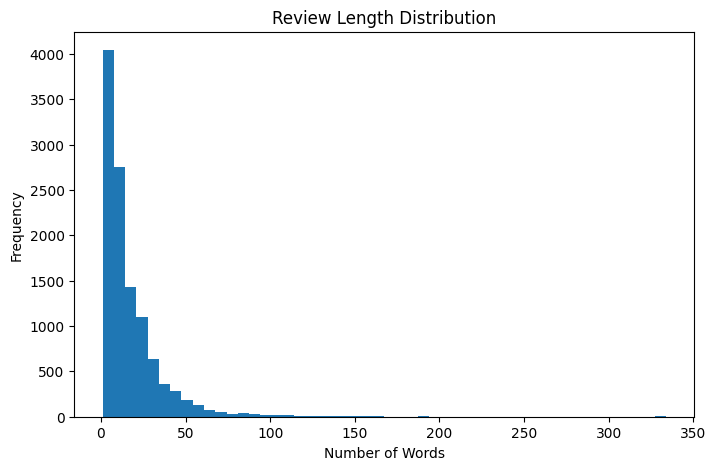

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(absa_v1["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Biểu đồ cho thấy phần lớn đánh giá có độ dài rất ngắn, tập trung ở khoảng 0–10 từ. Tần suất giảm nhanh khi số từ tăng, và chỉ có rất ít đánh giá vượt quá 100 từ. Phân bố lệch phải rõ rệt, phản ánh xu hướng người dùng viết đánh giá ngắn gọn, hiếm khi viết dài. Điều này phù hợp với thống kê mô tả trước đó và gợi ý rằng phần lớn nội dung đánh giá có thể mang tính khái quát hoặc cảm tính hơn là chi tiết.

In [8]:
aspects = [
    "description",
    "quality",
    "packaging",
    "delivery",
    "service",
    "price"
]

for aspect in aspects:
    print(absa_v1[aspect].value_counts())

description
neutral     7927
positive    2623
negative     711
Name: count, dtype: int64
quality
positive    7175
negative    2365
neutral     1721
Name: count, dtype: int64
packaging
neutral     8470
positive    2512
negative     279
Name: count, dtype: int64
delivery
neutral     7441
positive    3382
negative     438
Name: count, dtype: int64
service
neutral     8622
positive    2070
negative     569
Name: count, dtype: int64
price
neutral     8516
positive    2491
negative     254
Name: count, dtype: int64


Description: đa số trung lập, ít cảm xúc rõ rệt.  
Quality: phần lớn tích cực, cho thấy sự hài lòng về chất lượng.  
Packaging: chủ yếu trung lập, bao bì không phải yếu tố nổi bật.  
Delivery: nhiều đánh giá tích cực, dịch vụ giao hàng nhìn chung tốt.  
Service: đa số trung lập, trải nghiệm dịch vụ không gây ấn tượng mạnh.  
Price: phần lớn trung lập, giá cả không phải yếu tố chính trong đánh giá.

Tổng quan: người dùng tập trung khen ngợi chất lượng và giao hàng, còn các khía cạnh khác thường được đánh giá trung lập.


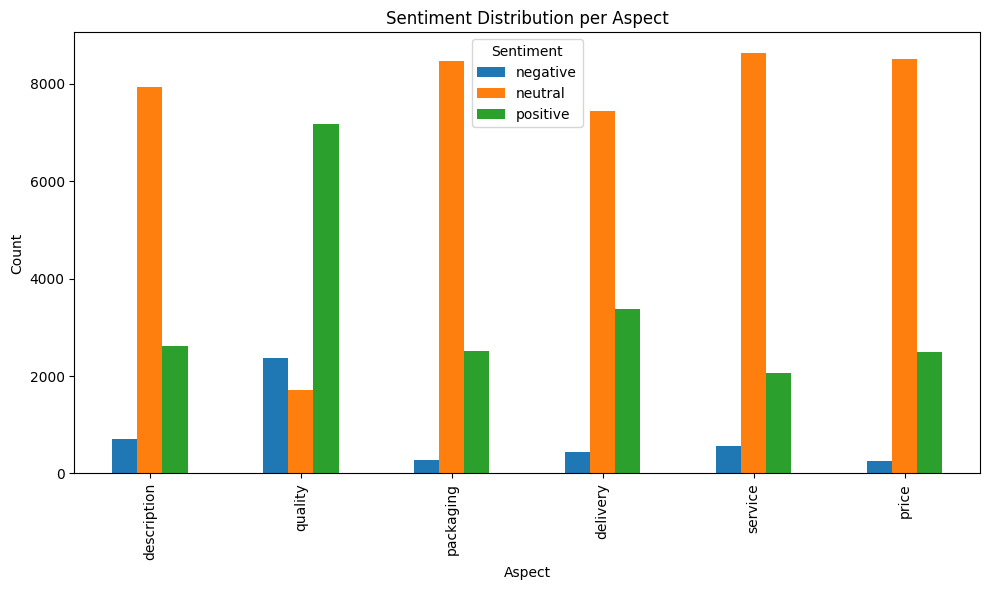

In [9]:
counts = {aspect: absa_v1[aspect].value_counts() for aspect in aspects}
df_counts = pd.DataFrame(counts).fillna(0)
df_counts = df_counts.T  

df_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Sentiment Distribution per Aspect")
plt.xlabel("Aspect")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

Biểu đồ thể hiện rõ xu hướng cảm xúc theo từng khía cạnh. Các cột trung lập chiếm ưu thế ở hầu hết các khía cạnh, đặc biệt là packaging, service và price. Chất lượng là khía cạnh có nhiều đánh giá tích cực nhất, cho thấy người dùng hài lòng với sản phẩm. Cảm xúc tiêu cực xuất hiện ít, tập trung ở mức thấp trên tất cả các khía cạnh. Tổng thể, dữ liệu phản ánh trải nghiệm người dùng chủ yếu trung lập hoặc tích cực, rất ít bất mãn rõ rệt.


In [10]:
absa_v1.head()

,text,description,quality,packaging,delivery,service,price,review_length
0,thuốc diệt chuột của hãng này quá phổ biến dùn...,neutral,positive,positive,positive,positive,positive,29
1,sản phẩm đẹp chất lượng ok,neutral,positive,neutral,neutral,neutral,neutral,6
2,đẹp tốt,positive,positive,positive,positive,positive,positive,2
3,đẹp bền,positive,positive,positive,positive,positive,positive,2
4,bé hơn nhiều so với mình tưởng tượng,negative,neutral,neutral,neutral,neutral,neutral,8


## Version 2

In [2]:
absa_v2 = pd.read_json('../data/absa/v2/full_dataset.json')

In [3]:
absa_v2.shape

(11269, 7)

In [4]:
absa_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11269 entries, 0 to 11268
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         11269 non-null  object
 1   description  11269 non-null  object
 2   quality      11269 non-null  object
 3   packaging    11269 non-null  object
 4   delivery     11269 non-null  object
 5   service      11269 non-null  object
 6   price        11269 non-null  object
dtypes: object(7)
memory usage: 616.4+ KB


In [5]:
absa_v2.isnull().sum()

text           0
description    0
quality        0
packaging      0
delivery       0
service        0
price          0
dtype: int64

Dữ liệu không có giá trị thiếu.

In [6]:
absa_v2["review_length"] = absa_v2["text"].astype(str).apply(lambda x: len(x.split()))
absa_v2["review_length"].describe()

count    11269.000000
mean        16.909664
std         19.809109
min          1.000000
25%          5.000000
50%         11.000000
75%         22.000000
max        334.000000
Name: review_length, dtype: float64

Dữ liệu cho thấy độ dài trung bình của đánh giá là khoảng 17 từ, với độ lệch chuẩn gần 20, phản ánh sự chênh lệch khá lớn giữa các bài viết. Phần lớn đánh giá ngắn, tập trung quanh giá trị trung vị 11 từ, trong khi một số ít đánh giá rất dài (tối đa 334 từ). Phân bố lệch phải rõ rệt, cho thấy người dùng thường viết ngắn gọn, chỉ một số ít cung cấp nhận xét chi tiết hơn.


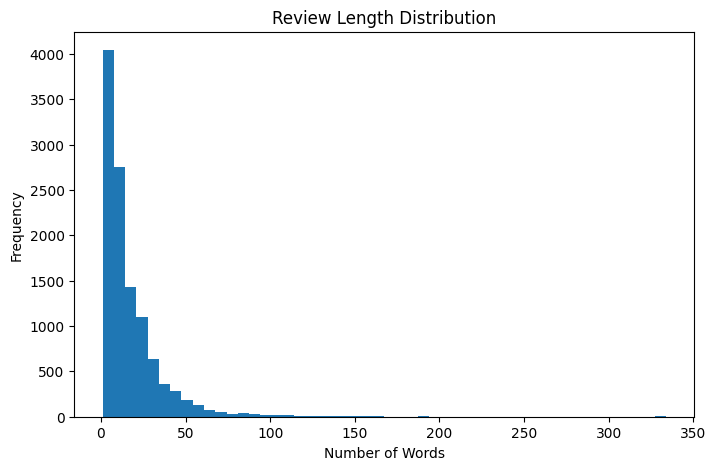

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(absa_v2["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Biểu đồ cho thấy phần lớn đánh giá có độ dài rất ngắn, tập trung trong khoảng 0–10 từ. Tần suất giảm nhanh khi số từ tăng, và chỉ có một số ít đánh giá vượt quá 100 từ. Phân bố lệch phải rõ rệt, phản ánh xu hướng người dùng viết đánh giá ngắn gọn, hiếm khi viết dài. Điều này phù hợp với thống kê mô tả trước đó, cho thấy phần lớn nội dung đánh giá mang tính khái quát hơn là chi tiết.


In [8]:
aspects = [
    "description",
    "quality",
    "packaging",
    "delivery",
    "service",
    "price"
]

for aspect in aspects:
    print(absa_v2[aspect].value_counts())

description
neutral     7933
positive    2624
negative     712
Name: count, dtype: int64
quality
positive    7180
negative    2367
neutral     1722
Name: count, dtype: int64
packaging
neutral     8475
positive    2515
negative     279
Name: count, dtype: int64
delivery
neutral     7446
positive    3385
negative     438
Name: count, dtype: int64
service
neutral     8629
positive    2071
negative     569
Name: count, dtype: int64
price
neutral     8522
positive    2493
negative     254
Name: count, dtype: int64


Description: phần lớn trung lập, ít cảm xúc rõ rệt.  
Quality: chủ yếu tích cực, thể hiện sự hài lòng về chất lượng sản phẩm.  
Packaging: đa số trung lập, bao bì không phải yếu tố nổi bật.  
Delivery: nhiều đánh giá tích cực, dịch vụ giao hàng được đánh giá tốt.  
Service: phần lớn trung lập, trải nghiệm dịch vụ không gây ấn tượng mạnh.  
Price: chủ yếu trung lập, giá cả không phải yếu tố chính trong đánh giá.

Tổng quan: người dùng có xu hướng đánh giá tích cực về chất lượng và giao hàng, trong khi các khía cạnh khác thường được nhận xét trung lập.


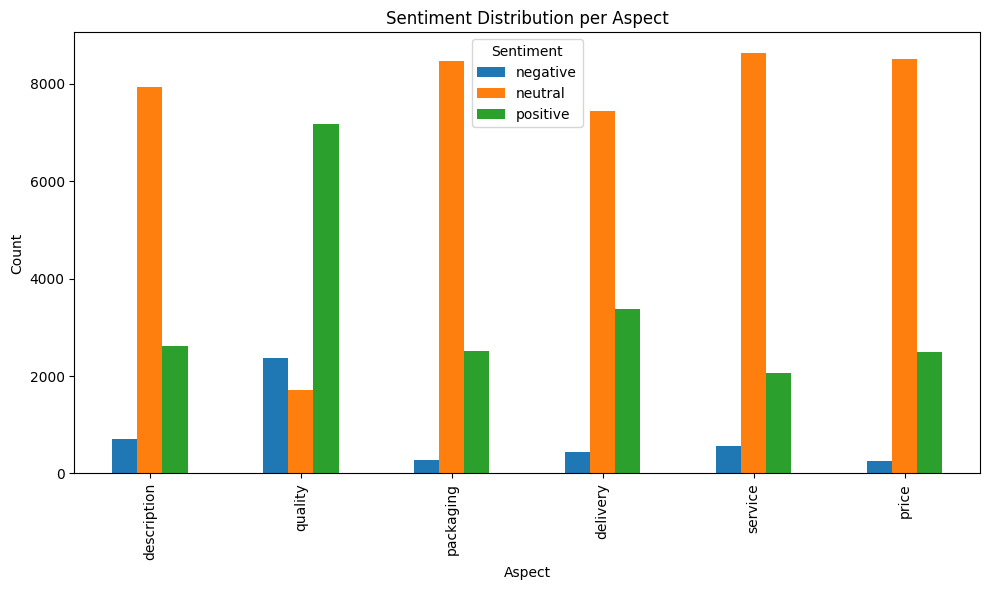

In [9]:
counts = {aspect: absa_v2[aspect].value_counts() for aspect in aspects}
df_counts = pd.DataFrame(counts).fillna(0)
df_counts = df_counts.T  

df_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Sentiment Distribution per Aspect")
plt.xlabel("Aspect")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

Biểu đồ thể hiện rõ sự khác biệt về cảm xúc giữa các khía cạnh. Các cột trung lập chiếm ưu thế ở hầu hết các khía cạnh, đặc biệt là packaging, service và price. Chất lượng là khía cạnh có nhiều đánh giá tích cực nhất, cho thấy người dùng hài lòng với sản phẩm. Cảm xúc tiêu cực xuất hiện ít, tập trung ở mức thấp trên tất cả các khía cạnh. Tổng thể, dữ liệu phản ánh trải nghiệm người dùng chủ yếu trung lập hoặc tích cực, rất ít bất mãn rõ rệt.


In [10]:
absa_v2.head()

,text,description,quality,packaging,delivery,service,price,review_length
0,thuốc diệt chuột của hãng này quá phổ biến dùn...,neutral,positive,positive,positive,positive,positive,29
1,sản phẩm đẹp chất lượng ok,neutral,positive,neutral,neutral,neutral,neutral,6
2,đẹp tốt,positive,positive,positive,positive,positive,positive,2
3,đẹp bền,positive,positive,positive,positive,positive,positive,2
4,bé hơn nhiều so với mình tưởng tượng,negative,neutral,neutral,neutral,neutral,neutral,8
